# 🔑 Setting Up Your Copernicus Data Store (CDS) API Token

When using the **Copernicus Data Store (CDS)** or **Atmosphere Data Store (ADS)** with the `cdsapi` Python client, you must authenticate using a **personal access token**.  
Without it, you’ll see errors like:
```
HTTPError: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/…
dataset not found
```
This happens when the client cannot find your CDS token or is pointing to the wrong endpoint.

---

## 1. Get Your Personal Access Token

1. Go to the appropriate data store:
   - 🌍 **CDS:** [https://cds.climate.copernicus.eu](https://cds.climate.copernicus.eu)
   - ☁️ **ADS (CAMS data):** [https://ads.atmosphere.copernicus.eu](https://ads.atmosphere.copernicus.eu)

2. Log in with your account.

3. Click your name in the top-right corner → **Profile** → scroll down to find your **API key** (also called *Personal Access Token*).

---

## 2. Create or Update the `.cdsapirc` File

Create a file named `.cdsapirc` in your **home directory** (e.g., `/home/jovyan/.cdsapirc` ).

Paste the following content:

For CDS:
```yaml
url: https://cds.climate.copernicus.eu/api
key: <YOUR-PERSONAL-ACCESS-TOKEN>
```
For ADS (CAMS data):

```yaml
url: https://ads.atmosphere.copernicus.eu/api
key: <YOUR-PERSONAL-ACCESS-TOKEN>
```

#!chmod 600 ~/.cdsapirc

## 3. download
**for cams, not working**
```
import cdsapi

dataset = "cams-global-reanalysis-eac4"
request = {
    "variable": ["total_column_ozone"],
    "date": ["2024-12-31/2024-12-31"],
    "time": ["00:00"],
    "grid": "N128",
    "data_format": "grib"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()
```

# Load the data in lat/lon

In [1]:
#!/usr/bin/env python
import cdsapi
import xarray as xr

# load the data in Gaussian grid

In [2]:
try:
    dsG = xr.open_dataset("outputG.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        #"param": "167.128", t2m
        "param": "34.128",
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid": "N512",
    }, "outputG.grib")
    dsG = xr.open_dataset("outputG.grib")
dsG

Ignoring index file 'outputG.grib.5b7b6.idx' older than GRIB file


<xarray.Dataset> Size: 77MB
Dimensions:     (number: 10, values: 1373624)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    (values) float64 11MB ...
    longitude   (values) float64 11MB ...
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    sst         (number, values) float32 55MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-30T09:58 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
dsG.sst.shape

(10, 1373624)

In [4]:
import matplotlib.pyplot as plt
import healpix_geo as hg
import healpy as hp
import numpy as np

In [5]:
level=9

# Compute weights for the ERA5 regridding

## Purpose

Compute, for each **HEALPix (NESTED) pixel center** at a target resolution, the **K nearest points** from an input **Gaussian grid** (e.g., ECMWF), using a **GPU-accelerated exact search**.

The method avoids global brute force by exploiting the **HEALPix quad-tree hierarchy** and **vectorized GPU distance evaluation**.

---

## Core Idea

### Spatial restriction with a coarse HEALPix index
1. Project all Gaussian points onto a **coarse HEALPix grid** (`level_coarse`).
2. For each coarse pixel, build a **candidate set** of Gaussian points from:
   - the coarse pixel itself
   - its 8 neighbors (`hp.get_all_neighbours`)
3. Process all fine-resolution children of the coarse pixel **in one GPU batch**.

### Fast exact distances on the sphere
Represent points as **unit vectors** in 3D. For unit vectors `a` and `b`:

$||a - b||^2 = 2 - 2 * (a · b)$


Distances become a matrix product + top-k:

- `dots = vh @ vg.T`
- `dist2 = 2 - 2*dots`
- `topk(dist2)` gives the K nearest Gaussian points.

---

## Why It’s Fast

- **NESTED contiguity**: children of a coarse pixel form a **contiguous block** at finer levels.
- The expensive step is a GPU GEMM per coarse pixel, not a global search.
- Complexity reduces from `O(N_heal * N_gauss)` to roughly `O(N_coarse * N_child * N_candidates)`.

---

## Main Components

### `HealpixKNNConfig`
Configuration for resolution, KNN, and GPU settings.

Key fields:
- `level`: target HEALPix level
- `level_coarse`: coarse level used for candidate restriction (`<= level`)
- `n_neighbors`: K
- `device`: usually `"cuda"`
- `dtype`: typically `float32`
- `max_candidates` (optional): cap neighborhood candidates to avoid extreme density cases

### `_latlon_to_unitvec_n3(lat, lon) -> (N,3)`
Convert Gaussian lat/lon (degrees) to unit vectors with guaranteed shape `(N,3)`.

### `_pix_to_unitvec_n3(nside, ipix, nest=True) -> (N,3)`
Convert HEALPix pixel indices to unit vectors (pixel centers), shape `(N,3)`.

### `build_healpix_gauss_knn(...)`
Main function returning:
- `knn_idx`: `(N_heal, K)` Gaussian indices
- `knn_dist2` (optional): `(N_heal, K)` squared distances

Algorithm steps:
1. Gaussian vectors `(Ng,3)` (CPU→GPU)
2. HEALPix fine vectors `(Nheal,3)` (GPU)
3. Assign Gaussian points to coarse pixels
4. Precompute coarse neighbors
5. Loop over coarse pixels:
   - gather candidates
   - load child HEALPix block
   - compute `dist2` on GPU
   - `topk` → fill outputs

---

## Recommended Settings

Typical starting point:

| target `level` | suggested `level_coarse` |
|---:|---:|
| 7 | 4–5 |
| 8 | 5–6 |
| 9 | 6–7 |

Notes:
- Increasing `level_coarse` reduces candidates (faster, less memory).
- `max_candidates` can be used as a safety valve (e.g., 5000–20000).

---

## Output Semantics

- `knn_idx[i, :]` are indices into the original Gaussian point list.
- `knn_dist2[i, :]` are exact squared distances on the unit sphere.
- Pixels with no candidates remain filled with `-1` (and `inf` for distances if requested).

---

## Summary

This approach provides **exact KNN on the sphere**, scalable to large grids, by combining:
- HEALPix hierarchy (coarse-to-fine restriction)
- NESTED memory contiguity (batch children)
- GPU matrix multiplication + top-k (fast exact distances)


In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import torch

from healpix_geo import nested  # healpix-geo


@dataclass(frozen=True)
class HealpixGeoKNNConfig:
    level: int
    level_coarse: int
    n_neighbors: int
    ellipsoid: str = "WGS84"
    device: str = "cuda"
    dtype: torch.dtype = torch.float32
    max_candidates: Optional[int] = None  # Optional safety cap per coarse pixel


def _lonlat_deg_to_ecef_wgs84(lon_deg: np.ndarray, lat_deg: np.ndarray) -> np.ndarray:
    """
    Convert lon/lat (degrees) to ECEF XYZ (meters) using WGS84.
    Returns (N, 3) float32.

    This uses the standard geodetic-to-ECEF formula.
    """
    lon = np.deg2rad(np.asarray(lon_deg, dtype=np.float64))
    lat = np.deg2rad(np.asarray(lat_deg, dtype=np.float64))

    # WGS84 parameters
    a = 6378137.0
    f = 1.0 / 298.257223563
    e2 = f * (2.0 - f)

    sin_lat = np.sin(lat)
    cos_lat = np.cos(lat)
    sin_lon = np.sin(lon)
    cos_lon = np.cos(lon)

    # Prime vertical radius of curvature
    N = a / np.sqrt(1.0 - e2 * sin_lat * sin_lat)

    # Altitude set to 0 (surface)
    x = N * cos_lat * cos_lon
    y = N * cos_lat * sin_lon
    z = (N * (1.0 - e2)) * sin_lat

    return np.stack([x, y, z], axis=1).astype(np.float32, copy=False)/a


def build_healpix_geo_gauss_knn(
    lat_gauss_deg: np.ndarray,
    lon_gauss_deg: np.ndarray,
    cfg: HealpixGeoKNNConfig,
    return_dist2: bool = False,
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """
    Compute KNN from each HEALPix pixel center (fine grid) to Gaussian points,
    using healpix-geo (no healpy). Ellipsoid can be WGS84.

    The algorithm:
    - Index Gaussian points into a coarse HEALPix grid (nested, ellipsoid-aware).
    - For each coarse pixel, build candidates from ring-1 neighbourhood.
    - Compute exact KNN within that candidate set on GPU using ECEF distances.

    Returns:
        knn_idx: (N_heal, K) indices into the Gaussian points
        knn_dist2: (N_heal, K) squared ECEF distances (optional)
    """
    if cfg.level_coarse > cfg.level:
        raise ValueError("level_coarse must be <= level")
    if cfg.n_neighbors <= 0:
        raise ValueError("n_neighbors must be > 0")

    level = cfg.level
    level_coarse = cfg.level_coarse
    k = cfg.n_neighbors
    ell = cfg.ellipsoid

    n_heal = 12 * (4**level)
    n_coarse = 12 * (4**level_coarse)

    # --- Gaussian points: lon/lat -> coarse ipix (CPU) ---
    ipix_gauss_c = nested.lonlat_to_healpix(
        longitude=np.asarray(lon_gauss_deg),
        latitude=np.asarray(lat_gauss_deg),
        depth=level_coarse,
        ellipsoid=ell,
    ).astype(np.int64, copy=False)

    # bins[p] = gaussian indices in coarse pixel p
    bins: list[list[int]] = [[] for _ in range(n_coarse)]
    for i, p in enumerate(ipix_gauss_c):
        bins[int(p)].append(i)

    # --- Precompute coarse neighbourhoods (CPU) ---
    # kth_neighbourhood returns (N, (2*ring+1)^2). ring=1 -> 9 entries
    # The center cell is at index 4 (doc says 5th element). Neighbours occupy other slots.
    neigh_c = nested.kth_neighbourhood(
        ipix=np.arange(n_coarse, dtype=np.uint64),
        depth=level_coarse,
        ring=1,
    ).astype(np.int64, copy=False)

    # --- HEALPix fine centers lon/lat on ellipsoid (CPU) ---
    # healpix_to_lonlat expects ipix array + depth + ellipsoid
    ipix_fine = np.arange(n_heal, dtype=np.uint64)
    lon_h, lat_h = nested.healpix_to_lonlat(ipix_fine, depth=level, ellipsoid=ell)
    lon_h = np.asarray(lon_h, dtype=np.float32)
    lat_h = np.asarray(lat_h, dtype=np.float32)

    # Convert HEALPix centers and Gaussian points to ECEF for distance computations
    v_heal_np = _lonlat_deg_to_ecef_wgs84(lon_h, lat_h)  # (Nheal,3)
    v_gauss_np = _lonlat_deg_to_ecef_wgs84(lon_gauss_deg, lat_gauss_deg)  # (Ng,3)

    v_heal = torch.as_tensor(v_heal_np, device=cfg.device, dtype=cfg.dtype)
    v_gauss = torch.as_tensor(v_gauss_np, device=cfg.device, dtype=cfg.dtype)

    # Outputs
    knn_idx = torch.full((n_heal, k), -1, device=cfg.device, dtype=torch.int64)
    knn_dist2 = (
        torch.full((n_heal, k), float("inf"), device=cfg.device, dtype=torch.float32)
        if return_dist2
        else None
    )

    # --- Optional: exploit nested contiguity (same assumption as healpy) ---
    dlevel = level - level_coarse
    n_child = 4**dlevel

    for p in range(n_coarse):
        # Candidate list from p neighbourhood (including p itself)
        cand: list[int] = []
        for q in neigh_c[p]:
            if q >= 0:
                cand.extend(bins[int(q)])

        if len(cand) == 0:
            continue

        # Optional cap for memory safety
        if cfg.max_candidates is not None and len(cand) > cfg.max_candidates:
            # Prefilter using ECEF dot-product proxy: keep closest to coarse center
            # Use coarse center lon/lat -> ECEF
            lon_c, lat_c = nested.healpix_to_lonlat(
                np.array([p], dtype=np.uint64), depth=level_coarse, ellipsoid=ell
            )
            vc = _lonlat_deg_to_ecef_wgs84(np.asarray(lon_c), np.asarray(lat_c))[0]  # (3,)
            vg = v_gauss_np[cand]  # (M,3)
            score = vg @ vc  # (M,)
            keep = np.argpartition(-score, cfg.max_candidates - 1)[: cfg.max_candidates]
            cand = [cand[i] for i in keep]

        cand_t = torch.as_tensor(cand, device=cfg.device, dtype=torch.int64)
        vg = v_gauss.index_select(0, cand_t)  # (M,3)

        # Fine children block (assumes nested child contiguity)
        start = p * n_child
        end = start + n_child
        vh = v_heal[start:end, :]  # (C,3)

        # Squared ECEF distance matrix: (C,M)
        # dist2 = ||vh||^2 + ||vg||^2 - 2*vh·vg
        vh2 = (vh * vh).sum(dim=1, keepdim=True)          # (C,1)
        vg2 = (vg * vg).sum(dim=1, keepdim=True).T        # (1,M)
        dots = vh @ vg.T                                   # (C,M)
        dist2 = (vh2 + vg2 - 2.0 * dots).to(torch.float32)

        top = torch.topk(dist2, k=k, largest=False, dim=1)
        idx_local = top.indices  # (C,k)

        knn_idx[start:end, :] = cand_t[idx_local]
        if knn_dist2 is not None:
            knn_dist2[start:end, :] = top.values

    knn_idx_cpu = knn_idx.detach().cpu().numpy()
    knn_dist2_cpu = knn_dist2.detach().cpu().numpy() if knn_dist2 is not None else None
    return knn_idx_cpu, knn_dist2_cpu

# compute the nearest N Gaussian grid points from each HEALPix cells 

In [7]:
Npt=9

cfg = HealpixGeoKNNConfig(
    level=level,
    level_coarse=level-3,
    n_neighbors=Npt,
    ellipsoid= "WGS84",
    device="cuda",
    max_candidates=20000,  # optional, can be None
)

knn_idx, knn_dist2 = build_healpix_geo_gauss_knn(
    lat_gauss_deg=dsG.latitude.values,
    lon_gauss_deg=dsG.longitude.values,
    cfg=cfg,
    return_dist2=True,
)


cfg = HealpixGeoKNNConfig(
    level=level,
    level_coarse=level-3,
    n_neighbors=Npt,
    ellipsoid= "sphere",
    device="cuda",
    max_candidates=20000,  # optional, can be None
)

knn_idx_sp, knn_dist2_sp = build_healpix_geo_gauss_knn(
    lat_gauss_deg=dsG.latitude.values,
    lon_gauss_deg=dsG.longitude.values,
    cfg=cfg,
    return_dist2=True,
)
heal_idx=np.repeat(np.arange(12*4**level),Npt).reshape(knn_idx.shape)

In [8]:
print('Ratio : ', dsG.latitude.values.shape[0],100*(12*4**level)/dsG.latitude.values.shape[0])

Ratio :  1373624 229.00939412823305


In [9]:
w=np.exp(-2*knn_dist2*4**level)
w/=np.sum(w,1)[:,None]

it=np.concatenate([knn_idx.ravel()[None,:],heal_idx.ravel()[None,:]],0)

M = torch.sparse_coo_tensor(it, w.ravel(), size=(dsG.latitude.values.shape[0],12*4**level), device='cuda', dtype=torch.float64).coalesce()

norm_trans=np.bincount(knn_idx.ravel(),w.ravel())

it=np.concatenate([heal_idx.ravel()[None,:],knn_idx.ravel()[None,:]],0)
MT = torch.sparse_coo_tensor(it, w.ravel()/norm_trans[knn_idx.ravel()],
                             size=(12*4**level,dsG.latitude.values.shape[0]), 
                             device='cuda', dtype=torch.float64).coalesce()
M = M.coalesce().to_sparse_csr().to('cuda')
MT = MT.coalesce().to_sparse_csr().to('cuda')
im=(torch.tensor(dsG.sst[0].values, device='cuda', dtype=torch.float64)@M).cpu().numpy()

/tmp/ipykernel_13189/3646915023.py:14: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  M = M.coalesce().to_sparse_csr().to('cuda')


In [10]:
w=np.exp(-2*knn_dist2_sp*4**level)
w/=np.sum(w,1)[:,None]

it=np.concatenate([knn_idx_sp.ravel()[None,:],heal_idx.ravel()[None,:]],0)

M_sp = torch.sparse_coo_tensor(it, w.ravel(), size=(dsG.latitude.values.shape[0],12*4**level), device='cuda', dtype=torch.float64).coalesce()

norm_trans=np.bincount(knn_idx_sp.ravel(),w.ravel())
it=np.concatenate([heal_idx.ravel()[None,:],knn_idx_sp.ravel()[None,:]],0)
MT_sp = torch.sparse_coo_tensor(it, w.ravel()/norm_trans[knn_idx_sp.ravel()],
                             size=(12*4**level,dsG.latitude.values.shape[0]), 
                             device='cuda', dtype=torch.float64).coalesce()
M_sp = M_sp.coalesce().to_sparse_csr().to('cuda')
MT_sp = MT_sp.coalesce().to_sparse_csr().to('cuda')

im_sp=(torch.tensor(dsG.sst[0].values, device='cuda', dtype=torch.float64)@M_sp).cpu().numpy()

In [11]:
plt.plot(knn_dist2[0:10].T*4**level)
#plt.yscale('log')
w.min(),w[0]

(np.float32(4.454048e-08),
 array([9.6448141e-01, 1.5589390e-02, 7.8388378e-03, 7.8388378e-03,
        3.9416151e-03, 1.2670300e-04, 1.2670300e-04, 2.8271264e-05,
        2.8271264e-05], dtype=float32))

In [12]:
@torch.no_grad()
def conjugate_gradient(
    A_mv: Callable[[torch.Tensor], torch.Tensor],
    b: torch.Tensor,
    x0: Optional[torch.Tensor] = None,
    max_iter: int = 200,
    tol: float = 1e-6,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Solve A x = b with Conjugate Gradient where A is SPD, using only matvec A_mv(v).
    No autograd (uses torch.no_grad).

    Returns:
        x: solution
        info: dict with residual norms history, iterations
    """
    if x0 is None:
        x = torch.zeros_like(b)
    else:
        x = x0.clone()

    r = b - A_mv(x)          # residual
    p = r.clone()
    rs_old = torch.einsum('ik,ik->i',r,r)

    b_norm = torch.linalg.norm(b)
    if b_norm == 0:
        return x, {"residual_norms": torch.tensor([0.0], device=b.device, dtype=b.dtype),
                   "iters": torch.tensor(0, device=b.device)}

    residual_norms = [torch.sqrt(rs_old)]

    for k in range(max_iter):
        Ap = A_mv(p)
        denom = torch.einsum('ik,ik->i',p,Ap)
        if torch.max(denom.abs()) < 1e-30:
            break  # breakdown (shouldn't happen for SPD unless numerical issues)

        alpha = rs_old / denom
        x = x + torch.einsum('k,ki->ki',alpha,p)
        r = r - torch.einsum('k,ki->ki',alpha,Ap)
        rs_new = torch.einsum('ik,ik->i',r,r)

        residual_norms.append(torch.sqrt(rs_new))

        # stopping criterion: relative residual
        if torch.max(torch.sqrt(rs_new)) <= tol * b_norm:
            rs_old = rs_new
            break

        beta = rs_new / rs_old
        p = r + torch.einsum('k,ki->ki',beta,p)
        rs_old = rs_new
        print(rs_old)

    info = {
        "residual_norms": torch.stack(residual_norms),
        "iters": torch.tensor(len(residual_norms) - 1, device=b.device),
    }
    return x, info


@torch.no_grad()
def least_squares_cg(M,MT,y,x_ref,x0, max_iter = 200,tol = 1e-6,damp = 0.0):
    """
    Solve min || M x - y ||_2^2 using CG on normal equations:
        (M^T M + damp*I) x = M^T y
    without explicitly forming M^T M.

    Args:
        M: [N1, N2]
        y: [N1]
        damp: optional Tikhonov regularization (lambda), solves min ||Mx-y||^2 + damp||x||^2
    """
    # b = M^T y
    b = (y - x_ref@M) @ MT

    def A_mv(v: torch.Tensor) -> torch.Tensor:
        # (M^T M + damp I) v
        return (v@M) @ MT + damp * v

    x, info = conjugate_gradient(A_mv=A_mv, b=b, x0=x0, max_iter=max_iter, tol=tol)
    return x, info
device = "cuda" if torch.cuda.is_available() else "cpu"

dtype = torch.float64  # souvent mieux pour CG

In [13]:
%%time
im=(torch.tensor(dsG.sst[0:1].values, device='cuda', dtype=torch.float64)@M).cpu().numpy()

x0 = torch.tensor(np.zeros([1,12*4**level]),device=device,dtype=dtype)
x_ref = torch.tensor(im,device=device,dtype=dtype)
y  = torch.tensor(dsG.sst[0:1].values,device=device,dtype=dtype)

healpy_est,info = least_squares_cg(MT,M, y, x_ref,x0, max_iter=100, tol=1e-8, damp=0.0)
healpy_est=healpy_est[0]+x_ref[0]
im=im[0]

tensor([1583.4521], device='cuda:0', dtype=torch.float64)
tensor([164.6275], device='cuda:0', dtype=torch.float64)
tensor([25.6854], device='cuda:0', dtype=torch.float64)
tensor([3.9335], device='cuda:0', dtype=torch.float64)
tensor([0.5410], device='cuda:0', dtype=torch.float64)
tensor([0.0648], device='cuda:0', dtype=torch.float64)
tensor([0.0089], device='cuda:0', dtype=torch.float64)
tensor([0.0013], device='cuda:0', dtype=torch.float64)
tensor([0.0002], device='cuda:0', dtype=torch.float64)
tensor([3.5974e-05], device='cuda:0', dtype=torch.float64)
tensor([6.2790e-06], device='cuda:0', dtype=torch.float64)
tensor([1.0714e-06], device='cuda:0', dtype=torch.float64)
tensor([1.8945e-07], device='cuda:0', dtype=torch.float64)
tensor([3.3309e-08], device='cuda:0', dtype=torch.float64)
tensor([6.4886e-09], device='cuda:0', dtype=torch.float64)
tensor([1.3941e-09], device='cuda:0', dtype=torch.float64)
tensor([3.3411e-10], device='cuda:0', dtype=torch.float64)
tensor([7.3953e-11], device

In [14]:
im_sp=(torch.tensor(dsG.sst[0:1].values, device='cuda', dtype=torch.float64)@M_sp).cpu().numpy()

x0 = torch.tensor(np.zeros([1,12*4**level]),device=device,dtype=dtype)
x_ref = torch.tensor(im_sp,device=device,dtype=dtype)
y  = torch.tensor(dsG.sst[0:1].values,device=device,dtype=dtype)

healpy_est_sp,info = least_squares_cg(MT_sp,M_sp, y, x_ref,x0, max_iter=100, tol=1e-8, damp=0.0)
healpy_est_sp=healpy_est_sp[0]+x_ref[0]
im_sp=im_sp[0]

tensor([1593.8450], device='cuda:0', dtype=torch.float64)
tensor([153.3114], device='cuda:0', dtype=torch.float64)
tensor([23.0023], device='cuda:0', dtype=torch.float64)
tensor([3.4525], device='cuda:0', dtype=torch.float64)
tensor([0.4978], device='cuda:0', dtype=torch.float64)
tensor([0.0590], device='cuda:0', dtype=torch.float64)
tensor([0.0080], device='cuda:0', dtype=torch.float64)
tensor([0.0011], device='cuda:0', dtype=torch.float64)
tensor([0.0002], device='cuda:0', dtype=torch.float64)
tensor([2.6291e-05], device='cuda:0', dtype=torch.float64)
tensor([4.0833e-06], device='cuda:0', dtype=torch.float64)
tensor([6.1076e-07], device='cuda:0', dtype=torch.float64)
tensor([9.5937e-08], device='cuda:0', dtype=torch.float64)
tensor([1.3866e-08], device='cuda:0', dtype=torch.float64)
tensor([1.9957e-09], device='cuda:0', dtype=torch.float64)
tensor([2.7600e-10], device='cuda:0', dtype=torch.float64)
tensor([3.9977e-11], device='cuda:0', dtype=torch.float64)
tensor([6.4166e-12], device

In [15]:
import xdggs

def healpix_im_to_xarray(
    im: np.ndarray,
    level: int,
    nest: bool = True,
    name: str = "data",
    ellipsoid: str ="WGS84",
) -> xr.DataArray:
    """
    Convert a 1D HEALPix array (size = 12*nside^2) into an xarray.DataArray
    compatible with xdggs.

    Parameters
    ----------
    im : np.ndarray
        1D array of length 12*nside^2 (HEALPix pixels)
    nside : int
        HEALPix nside
    nest : bool
        True for NESTED indexing (recommended for xdggs)
    name : str
        Name of the data variable

    Returns
    -------
    xr.DataArray
    """
    npix = 12 * 4**level
    if im.ndim != 1 or im.size != npix:
        raise ValueError(f"im must have shape ({npix},), got {im.shape}")

    # Build HEALPix DGGS
    dggs = xdggs.HealpixInfo(level=level, indexing_scheme="nested" if nest else "ring", ellipsoid=ellipsoid)

    # HEALPix cell ids (integer ipix)
    cell_ids = np.arange(npix, dtype=np.int64)

    da = xr.DataArray(
        im,
        dims=("cell",),
        coords={
            "cell_ids": ("cell", cell_ids),
        },
        name=name,
    )

    return da.dggs.decode(dggs)

da_WGS84 = healpix_im_to_xarray(im, level=level)
da_SPHERE = healpix_im_to_xarray(im_sp, level=level)

In [16]:
da_WGS84.dggs.explore(alpha=0.5)

In [17]:
da_SPHERE.dggs.explore(alpha=0.5)

In [25]:
hp.cartview(im-im_sp,nest=True,flip='geo',title='WGS84-SPHERE')

In [26]:
plt.figure(figsize=(16,12))
hp.orthview(im,flip='geo',nest=True,hold=False,sub=(2,2,1),title='Raw Regridded Map',rot=[0,30],cmap='jet',min=270,max=305)
hp.orthview(healpy_est.cpu().numpy(),flip='geo',nest=True,hold=False,sub=(2,2,2),title='Iterative Regridded Map',rot=[0,30],cmap='jet',min=270,max=305)
hp.orthview(np.log10(abs(im-healpy_est.cpu().numpy())),flip='geo',nest=True,hold=False,sub=(2,2,3),title='Difference Raw - Iterative',rot=[0,30],cmap='jet')
plt.subplot(2,2,4)
plt.title('Gaussian grid')
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=dsG.sst[0].values/(dsG.sst[0].values!=dsG.sst[0,-1].values),s=0.01,cmap='jet')
plt.colorbar()

r=(torch.tensor(healpy_est.cpu().numpy(),device='cuda')@MT).cpu().numpy()

/tmp/ipykernel_13189/544668984.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.scatter(dsG.longitude.values,dsG.latitude.values,c=dsG.sst[0].values/(dsG.sst[0].values!=dsG.sst[0,-1].values),s=0.01,cmap='jet')


Text(0, 0.5, '$\\Delta$T2m [K]')

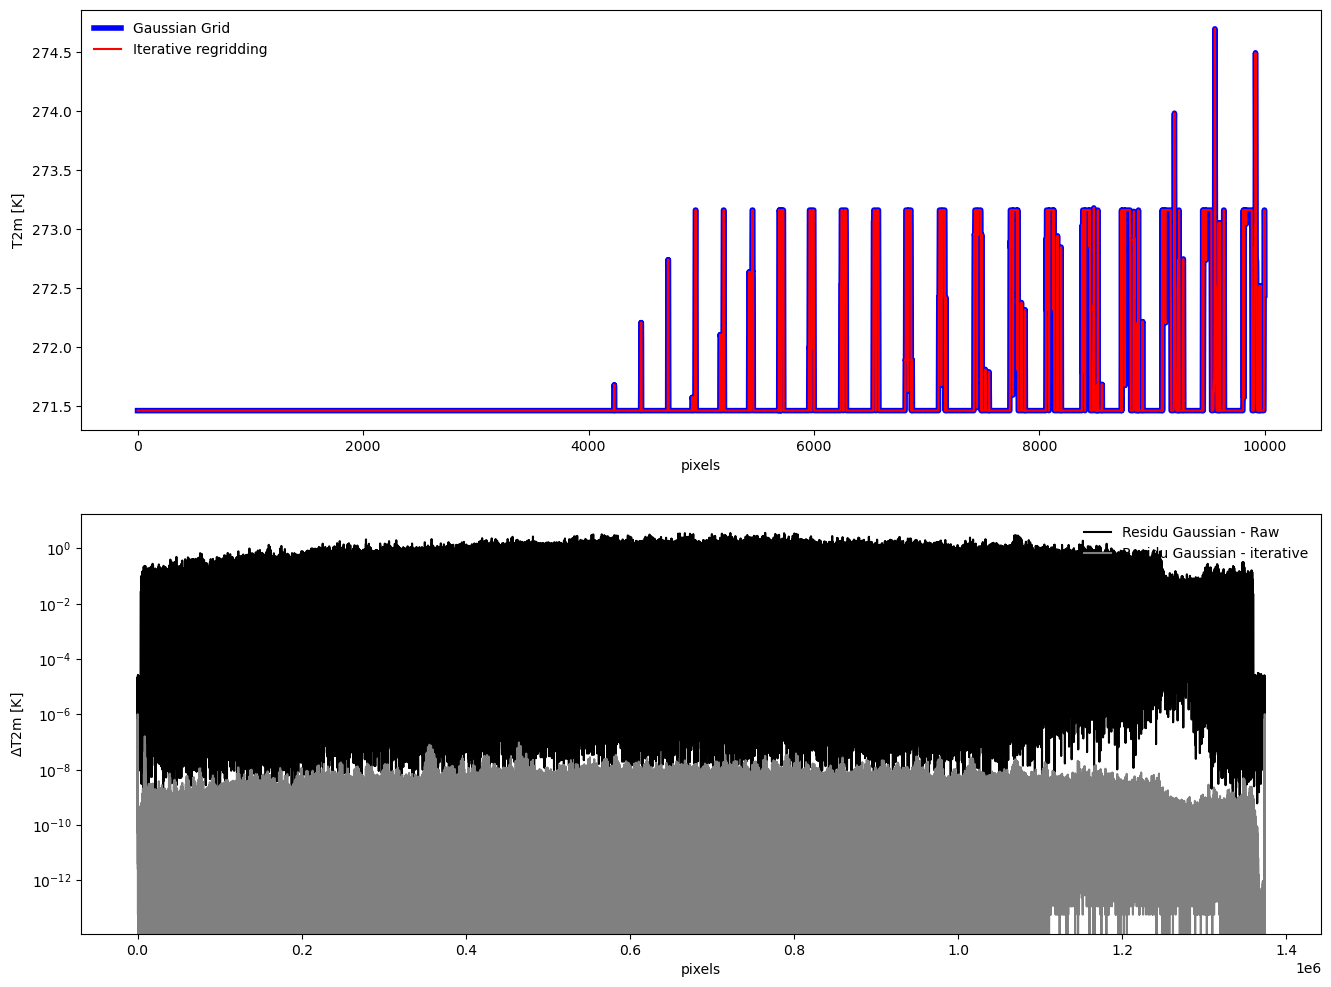

In [27]:
rinit=(torch.tensor(im,device='cuda')@MT).cpu().numpy()

plt.figure(figsize=(16,12))
plt.subplot(2,1,1)
plt.plot(dsG.sst[0,0:10000].values,color='b',lw=4,label='Gaussian Grid')
plt.plot(r[0:10000],color='r',label='Iterative regridding')
plt.legend(frameon=0)
plt.xlabel('pixels')
plt.ylabel('T2m [K]')
plt.subplot(2,1,2)
plt.plot(abs(rinit-dsG.sst[0].values),color='black',label='Residu Gaussian - Raw')
plt.plot(abs(r-dsG.sst[0].values),color='grey',label='Residu Gaussian - iterative')
plt.legend(frameon=0)
plt.xlabel('pixels')
plt.yscale('log')
plt.ylabel(r'$\Delta$T2m [K]')

In [28]:

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.title('Raw regridding')
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(rinit-dsG.sst[0].values)),s=0.1,vmin=-10,vmax=1,cmap='jet')
plt.colorbar(shrink=0.5,label=r'$log10(\sigma)$')
plt.subplot(1,3,2)
plt.title('Iterative regridding')
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(r-dsG.sst[0].values)),s=0.1,vmin=-10,vmax=1,cmap='jet')
plt.colorbar(shrink=0.5,label=r'$log10(\sigma)$')

/tmp/ipykernel_13189/1570928056.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(r-dsG.sst[0].values)),s=0.1,vmin=-10,vmax=1,cmap='jet')


/tmp/ipykernel_13189/113352273.py:3: RuntimeWarning: divide by zero encountered in log10
  hy2,hx=np.histogram(np.log10(abs(r-dsG.sst[0].values)),range=[-11,amp],bins=1001)


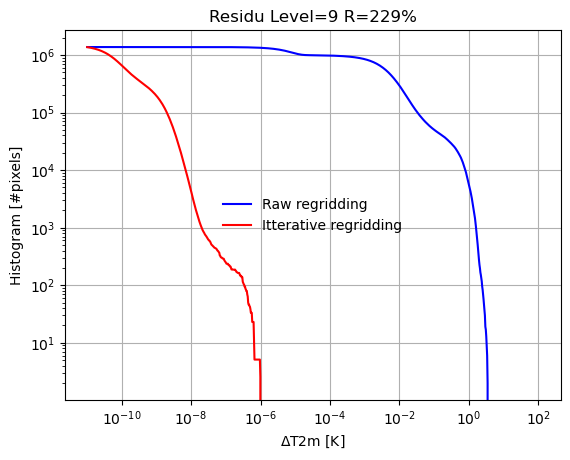

In [29]:
amp=2
hy,hx=np.histogram(np.log10(abs(rinit-dsG.sst[0].values)),range=[-11,amp],bins=1001)
hy2,hx=np.histogram(np.log10(abs(r-dsG.sst[0].values)),range=[-11,amp],bins=1001)
hy=np.cumsum(hy.astype('float'))
hy2=np.cumsum(hy2.astype('float'))
hy/=np.max(hy)
hy2/=np.max(hy2)
plt.title('Residu Level=%d R=%.0f%%'%(level,100*12*(4**level)/dsG.sst.shape[1]))
plt.plot(10**((hx[1:]+hx[:-1])/2),r.shape[0]*(1.0-hy),color='b',label='Raw regridding')
plt.plot(10**((hx[1:]+hx[:-1])/2),r.shape[0]*(1.0-hy2),color='r',label='Itterative regridding')
plt.legend(frameon=0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Delta$T2m [K]')
plt.ylabel('Histogram [#pixels]')
plt.grid()